# Shared variance: cognitive parameters vs. symptom surveys — a CCA ladder with SHARP inference

**Question.** How much shared variance between the fitted cognitive-task parameters and the symptom surveys generalizes to held-out subjects, and does added model flexibility help?

**Ladder of methods** (least → most flexible), 5 arms:
- `raw` — regularized linear CCA on standardized raw features, each view PCA-reduced to 10 components first (baseline)
- `kernel` — kernel CCA (RBF) directly (KCCA; not a linear CCA on top)
- `deep` — Deep CCA (trained MLP encoders) + linear CCA on the learned representations
- `fm` — frozen TabPFN v2 embeddings + linear CCA
- `tabfm` — frozen Google TabFM embeddings + linear CCA

The frozen FM arms (`fm`, `tabfm`) use **leakage-free cross-fitted embeddings**: each training row is embedded against a TabPFN/TabFM context built from *other* training rows only (never its own labeled support); test rows embed against the full-train context. The jointly **fine-tuned** FM arms (`fm_deep`, `tabfm_deep`) are **excluded** from the comparison — a leakage-free version needs nested cross-fit of the fine-tuning itself (the tuned weights see all train rows), which is computationally infeasible here.

Held-out canonical correlations are **signed** (a joint sign flip of both variates preserves r, so a negative held-out r means the fitted direction did not generalize — it is *not* folded to |r|).

**Cohort.** Training half only, `max_rhat>1.1` excluded — **N=1298**, the same cohort (and subject-set hash) as the Anna Karenina and XGBoost analyses.

**Inference — SHARP score test (paper-faithful).** SHARP splits subjects into two **disjoint** halves per repetition (stratified by `backfilled_prolific_screen_group`), runs K-fold CV within each, and identifies σ² and ρ from the within-repetition independence of the halves (Zeng et al. 2026). Inference is the paper's **null-constrained score test** with a **global** (multimodal-safe) profile optimizer and **test-inversion** 95% CIs — not the earlier method-of-moments + Wald (which inflated the FPR) nor a single bounded optimize (which could pick a non-global mode). The score test is valid but somewhat **conservative** at low/moderate ρ; the final run uses **J=60, K=5** (paper-scale). A within-strata permutation null gives a corroborating above-chance test (run at a coarser `J_perm`/`K_perm`, so its observed statistic differs from the main estimate and is shown separately).

**Compute.** `scripts/run_sharp_ladder.py` (multi-GPU) checkpoints `data/exploratory/sharp_ladder_results_rhat1p1.pkl`; this notebook loads and visualizes it.

```
SV_MAX_RHAT=1.1 uv run python scripts/run_sharp_ladder.py   # N=1298, J=60, all GPUs
```

In [1]:
import pickle
import itertools
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
# N=1298 cohort (max_rhat>1.1 excluded) -- matches the AK / XGBoost analyses.
RESULTS = Path("../data/exploratory/sharp_ladder_results_rhat1p1.pkl")
R = pickle.loads(RESULTS.read_bytes())
ARMS = R["arms"]
PERM_DONE = [a for a in ARMS if a in R["perms"]]
print(("QUICK" if R["quick"] else "FULL"), f"run | N={R['n_subjects']} | J={R['J']} K={R['K']}")
print("permutations per arm:", R["n_perm"])
print("permutation nulls available for:", PERM_DONE)
print(f"View A (cognitive): {len(R['a_columns'])} cols | View B (symptom): {len(R['b_columns'])} cols")
prov = R.get("provenance")
if prov:
    print(f"provenance: commit={str(prov.get('analysis_source_commit'))[:9]} stamp={str(prov.get('provenance_stamp_commit'))[:9]} dirty={prov.get('dirty')} "
          f"| training_csv={prov.get('training_csv_sha256','')[:12]} "
          f"| subject_set={prov.get('subject_set_sha256','')[:12]}")

FULL run | N=1298 | J=60 K=5
permutations per arm: {'raw': 1000, 'kernel': 1000, 'deep': 200, 'fm': 100, 'tabfm': 100}
permutation nulls available for: ['raw', 'kernel', 'deep', 'fm', 'tabfm']
View A (cognitive): 30 cols | View B (symptom): 20 cols
provenance: commit=051fa90f1 dirty=True | training_csv=e86542ef6b31 | subject_set=7c7f63c41674


## 1. Per-arm held-out canonical correlation with valid SHARP 95% CIs

In [2]:
cis, perms = R["cis"], R["perms"]
jp, kp = R.get("J_perm"), R.get("K_perm")
print(f"main estimate: J={R['J']}, K={R['K']}  |  permutation null: J_perm={jp}, K_perm={kp} "
      f"(coarser, so its 'obs(perm)' statistic differs from the main estimate)")
print(f"{'arm':8s} {'held-out r':>11s} {'95% CI':>20s} {'shared var':>11s} {'rho':>6s} {'obs(perm)':>10s} {'p_perm':>8s}")
for a in ARMS:
    c = cis[a]
    obs = f"{perms[a]['observed']:+.3f}" if a in perms else "   --"
    pp = f"{perms[a]['p']:.4f}" if a in perms else "   --"
    print(f"{a:8s} {c['mean']:>11.3f}  [{c['lo']:+.3f},{c['hi']:+.3f}] {c['shared_variance']:>11.4f} {c['rho']:>6.2f} {obs:>10s} {pp:>8s}")

main estimate: J=60, K=5  |  permutation null: J_perm=5, K_perm=3 (coarser, so its 'obs(perm)' statistic differs from the main estimate)
arm       held-out r               95% CI  shared var    rho  obs(perm)   p_perm
raw            0.085  [+0.018,+0.152]      0.0072   0.36     +0.078   0.0090
kernel         0.088  [+0.029,+0.147]      0.0077   0.24     +0.089   0.0100
deep           0.046  [+0.016,+0.076]      0.0021   0.14     +0.023   0.0249
fm            -0.006  [-0.045,+0.033]      0.0000   0.01     +0.002   0.3465
tabfm          0.059  [+0.001,+0.118]      0.0035   0.26     +0.052   0.0198


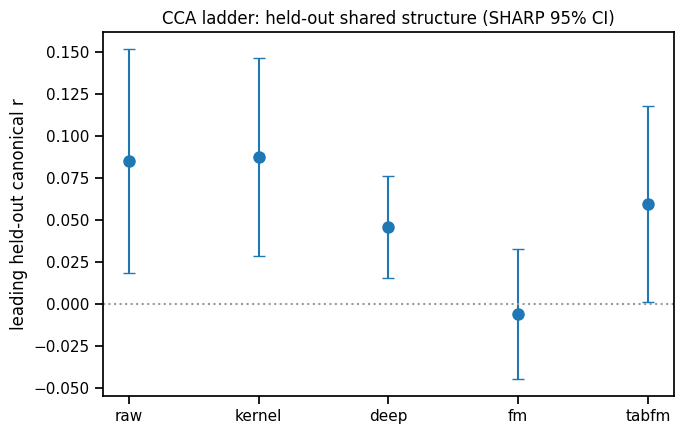

In [3]:
# Ladder plot: leading held-out canonical r with SHARP 95% CI
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(ARMS))
means = [cis[a]['mean'] for a in ARMS]
los = [cis[a]['mean'] - cis[a]['lo'] for a in ARMS]
his = [cis[a]['hi'] - cis[a]['mean'] for a in ARMS]
ax.errorbar(x, means, yerr=[los, his], fmt='o', capsize=4, ms=8, color='C0')
ax.axhline(0, ls=':', color='0.6')
ax.set_xticks(x); ax.set_xticklabels(ARMS)
ax.set_ylabel('leading held-out canonical r')
ax.set_title('CCA ladder: held-out shared structure (SHARP 95% CI)')
plt.tight_layout(); plt.show()

## 2. Pairwise SHARP comparisons (which rung wins?)

Paper-faithful score test on the paired per-half difference in held-out canonical r (fold-dependence-aware). There are C(5,2)=10 pairwise tests, so a Benjamini–Hochberg FDR q-value across the family is reported alongside the raw p. Note the sign: a significant `raw_vs_X` with a **positive** diff means `raw` is *better* (arm `X` does **not** beat raw).

comparison                 diff       z        p     q_BH
raw vs kernel            -0.003   -0.08   0.9338   0.9338
raw vs deep              +0.039   +2.04   0.0410   0.0820
raw vs fm                +0.091   +2.41   0.0162   0.0808
raw vs tabfm             +0.026   +0.94   0.3492   0.4328
kernel vs deep           +0.042   +1.69   0.0908   0.1514
kernel vs fm             +0.094   +2.42   0.0157   0.0808
kernel vs tabfm          +0.028   +0.86   0.3895   0.4328
deep vs fm               +0.052   +2.07   0.0388   0.0820
deep vs tabfm            -0.014   -1.11   0.2668   0.3811
fm vs tabfm              -0.066   -2.20   0.0275   0.0820

Pairwise comparisons surviving BH-FDR (q<0.05): 0 / 10


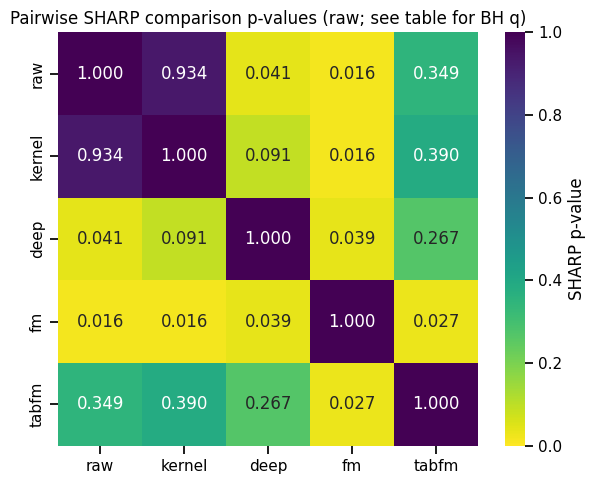

In [4]:
comparisons = R["comparisons"]

def _bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = np.empty(n); prev = 1.0
    for rank, i in enumerate(order[::-1]):
        prev = min(prev, p[i] * n / (n - rank)); q[i] = prev
    return q

pairs = list(itertools.combinations(ARMS, 2))
praw = np.array([comparisons[f"{a1}_vs_{a2}"]["p"] for a1, a2 in pairs])
qvals = _bh_fdr(praw)
print(f"{'comparison':22s} {'diff':>8s} {'z':>7s} {'p':>8s} {'q_BH':>8s}")
for (a1, a2), q in zip(pairs, qvals):
    c = comparisons[f"{a1}_vs_{a2}"]
    print(f"{a1+' vs '+a2:22s} {c['diff']:>+8.3f} {c['z']:>+7.2f} {c['p']:>8.4f} {q:>8.4f}")
print(f"\nPairwise comparisons surviving BH-FDR (q<0.05): {int((qvals<0.05).sum())} / {len(pairs)}")

P = np.ones((len(ARMS), len(ARMS)))
for (a1, a2) in pairs:
    c = comparisons[f"{a1}_vs_{a2}"]
    i, j = ARMS.index(a1), ARMS.index(a2)
    P[i, j] = P[j, i] = c['p']
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(P, annot=True, fmt='.3f', xticklabels=ARMS, yticklabels=ARMS,
            cmap='viridis_r', vmin=0, vmax=1, cbar_kws={'label': 'SHARP p-value'}, ax=ax)
ax.set_title('Pairwise SHARP comparison p-values (raw; see table for BH q)')
plt.tight_layout(); plt.show()

## 3. Above-chance test: within-strata permutation null

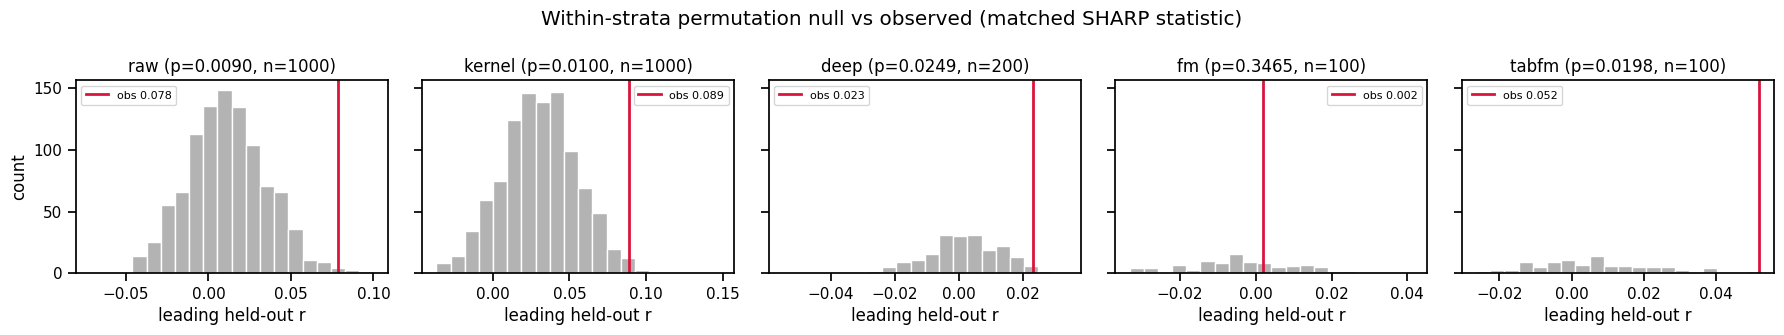

Arm-level permutation tests (BH-FDR across arms):
  raw      p_perm=0.0090  q_BH=0.0250  (n_perm=1000)
  kernel   p_perm=0.0100  q_BH=0.0250  (n_perm=1000)
  deep     p_perm=0.0249  q_BH=0.0311  (n_perm=200)
  fm       p_perm=0.3465  q_BH=0.3465  (n_perm=100)
  tabfm    p_perm=0.0198  q_BH=0.0311  (n_perm=100)
Perms use a coarser J_perm/K_perm than the main estimate -> treat the above-chance
test as corroborating, not primary; permutation counts (>=100) bound the p-floor.


In [5]:
if PERM_DONE:
    fig, axes = plt.subplots(1, len(PERM_DONE), figsize=(3.6 * len(PERM_DONE), 3.4), sharey=True)
    if len(PERM_DONE) == 1:
        axes = [axes]
    for ax, a in zip(axes, PERM_DONE):
        out = perms[a]
        ax.hist(out['null'], bins=20, color='0.7', edgecolor='white')
        ax.axvline(out['observed'], color='crimson', lw=2, label=f"obs {out['observed']:.3f}")
        ax.set_title(f"{a} (p={out['p']:.4f}, n={R['n_perm'][a]})")
        ax.set_xlabel('leading held-out r'); ax.legend(fontsize=8)
    axes[0].set_ylabel('count')
    plt.suptitle('Within-strata permutation null vs observed (matched SHARP statistic)')
    plt.tight_layout(); plt.show()
else:
    print('No permutation nulls in the results file yet.')

# BH-FDR across the arm-level permutation p-values (multiplicity across arms)
if PERM_DONE:
    pv = np.array([perms[a]['p'] for a in PERM_DONE])
    order = np.argsort(pv); q = np.empty(len(pv)); prev = 1.0
    for rank, i in enumerate(order[::-1]):
        prev = min(prev, pv[i] * len(pv) / (len(pv) - rank)); q[i] = prev
    print("Arm-level permutation tests (BH-FDR across arms):")
    for a, qq in zip(PERM_DONE, q):
        print(f"  {a:8s} p_perm={perms[a]['p']:.4f}  q_BH={qq:.4f}  (n_perm={R['n_perm'][a]})")
    print("Perms use a coarser J_perm/K_perm than the main estimate -> treat the above-chance")
    print("test as corroborating, not primary; permutation counts (>=100) bound the p-floor.")

## 4. Summary

Read off the tables/plots above:
- **Per-arm** held-out **leading** canonical r with **SHARP 95% CI** (score-test inversion), the implied **leading-dimension** shared variance (r² of the top canonical pair — *not* total multivariate shared variance), and the corroborating within-strata permutation p.
- **Pairwise** SHARP score tests (BH-FDR across the 10 comparisons): whether any flexible arm *beats* the linear `raw` baseline. A significant contrast in the direction of `raw` being larger means the flexible arm does **not** beat raw.

**Reporting language.** Estimates are *generalizable* (held-out), **signed** leading canonical correlations with valid SHARP uncertainty (null-constrained score test with a global profile optimizer + test-inversion CIs); naive across-fold/repeated-split CIs and the earlier MoM+Wald test are invalid/miscalibrated and not used. The score test is valid but **conservative** at low/moderate ρ (documented; J=60, K=5). "Shared variance" is the squared **leading** canonical correlation, a lower-dimensional summary, not total shared variance. The frozen FM arms use **leakage-free cross-fitted embeddings**; the fine-tuned FM arms are excluded (see §0). The maximum across rungs is a model/representation-conditional estimate, not an absolute maximum. Cohort: training half, `max_rhat>1.1` excluded (N=1298), stratified by `backfilled_prolific_screen_group`.